In [15]:
# cell 1 — connect to stores, load BM25 index, load embedder
import os, json, time, random
from pathlib import Path
import numpy as np
from dotenv import load_dotenv
from pymongo import MongoClient
from qdrant_client import QdrantClient
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, CrossEncoder

load_dotenv()
PROJECT_ROOT = Path('.').resolve().parent if Path('notebooks').exists() else Path('.').resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
RESULTS_DIR = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

mongo = MongoClient(os.getenv('MONGO_URI', 'mongodb://localhost:27017'))
db = mongo.csai415_rag
docs_col = db.documents
chunks_col = db.chunks

qdrant = QdrantClient(host=os.getenv('QDRANT_HOST', 'localhost'), port=int(os.getenv('QDRANT_PORT', 6333)))
embedder = SentenceTransformer('BAAI/bge-small-en-v1.5')

print(f'docs: {docs_col.count_documents({})}, chunks: {chunks_col.count_documents({})}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

docs: 144, chunks: 6858


In [16]:
# cell 2 — load all chunks into memory and build BM25 index
all_chunks = list(chunks_col.find({}, {'_id': 0}))
tokenised = [c['text'].lower().split() for c in all_chunks]
bm25 = BM25Okapi(tokenised)
print(f'BM25 index built over {len(all_chunks)} chunks')

BM25 index built over 6858 chunks


In [17]:
# cell 3 — load reranker (downloads ~278 MB on first run)
reranker = CrossEncoder('BAAI/bge-reranker-base', max_length=512)
print('reranker loaded')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

reranker loaded


In [18]:
# cell 4 — build expanded gold set (30 queries auto-generated from abstracts)
# we sample 30 papers and use the first 20 words of each abstract as the query.
# the source paper is the relevant document.

random.seed(42)

all_docs = list(docs_col.find({}, {'_id': 1, 'title': 1, 'abstract': 1, 'authors': 1, 'year': 1}))
candidates = [d for d in all_docs if d.get('abstract') and len(d['abstract'].split()) >= 25]
sample = random.sample(candidates, min(30, len(candidates)))

expanded_gold = []
for d in sample:
    words = d['abstract'].split()
    query = ' '.join(words[:20])
    expanded_gold.append({
        'query'       : query,
        'relevant_doc': d.get('doc_id', str(d['_id'])),
        'title'       : d.get('title'),
        'authors'     : d.get('authors'),
        'year'        : d.get('year'),
    })

with open(PROJECT_ROOT / 'data' / 'gold_set_d2.json', 'w') as f:
    json.dump(expanded_gold, f, indent=2, default=str)

print(f'expanded gold set: {len(expanded_gold)} queries saved to data/gold_set_d2.json')
print('first 3 queries:')
for g in expanded_gold[:3]:
    print(f'  [{g["year"]}] {g["query"][:80]}...  →  {g["title"][:60]}')

expanded gold set: 10 queries saved to data/gold_set_d2.json
first 3 queries:
  [2024] Retrieval-Augmented Generation (RAG) enhances Large Language Models (LLMs) by in...  →  A Collaborative Multi-Agent Approach to Retrieval-Augmented 
  [2024] This research presents and compares multiple approaches to automate the generati...  →  Automated Literature Review Using NLP Techniques and LLM-Bas
  [2025] Accurate and contextually faithful responses are critical when applying large la...  →  Investigating Retrieval-Augmented Generation in Quranic Stud


In [19]:
# cell 5 — retrieval functions: dense, sparse, hybrid (RRF), hybrid+rerank
QDRANT_COLLECTION = 'csai415_papers'

def dense_search(query, top_k=20):
    qv = embedder.encode(query, normalize_embeddings=True)
    hits = qdrant.query_points(collection_name=QDRANT_COLLECTION, query=qv.tolist(), limit=top_k).points
    return [(h.payload['doc_id'], h.payload.get('chunk_idx', 0), float(h.score)) for h in hits]

def sparse_search(query, top_k=20):
    scores = bm25.get_scores(query.lower().split())
    top_idx = np.argsort(scores)[::-1][:top_k]
    return [(all_chunks[i]['doc_id'], all_chunks[i].get('chunk_idx', i), float(scores[i])) for i in top_idx]

def rrf_merge(rankings, k=60, top_k=20):
    scores = {}
    for ranking in rankings:
        for rank, item in enumerate(ranking, 1):
            key = (item[0], item[1])
            scores[key] = scores.get(key, 0) + 1 / (k + rank)
    merged = sorted(scores.items(), key=lambda x: -x[1])
    return [(key[0], key[1], score) for key, score in merged[:top_k]]

def hybrid_search(query, top_k=20):
    d = dense_search(query, top_k=50)
    s = sparse_search(query, top_k=50)
    return rrf_merge([d, s], top_k=top_k)

def rerank(query, candidates, top_k=5):
    # candidates: list of (doc_id, chunk_idx, score)
    chunk_lookup = {(c['doc_id'], c.get('chunk_idx', i)): c['text'] for i, c in enumerate(all_chunks)}
    pairs, kept = [], []
    for doc_id, chunk_idx, _ in candidates:
        txt = chunk_lookup.get((doc_id, chunk_idx))
        if txt:
            pairs.append([query, txt[:512]])
            kept.append((doc_id, chunk_idx))
    if not pairs:
        return []
    scores = reranker.predict(pairs)
    paired = sorted(zip(kept, scores), key=lambda x: -x[1])[:top_k]
    return [(k[0], k[1], float(s)) for k, s in paired]

print('retrieval functions ready')

retrieval functions ready


In [20]:
# cell 6 — IR metrics: Recall@k, MRR, nDCG@k, Precision@k
def get_doc_ids(results):
    seen, out = set(), []
    for r in results:
        doc_id = r[0]
        if doc_id not in seen:
            seen.add(doc_id)
            out.append(doc_id)
    return out

def recall_at_k(retrieved_doc_ids, relevant_doc, k):
    return 1.0 if relevant_doc in retrieved_doc_ids[:k] else 0.0

def precision_at_k(retrieved_doc_ids, relevant_doc, k):
    return (1.0 / k) if relevant_doc in retrieved_doc_ids[:k] else 0.0

def mrr(retrieved_doc_ids, relevant_doc):
    for i, d in enumerate(retrieved_doc_ids, 1):
        if d == relevant_doc:
            return 1.0 / i
    return 0.0

def ndcg_at_k(retrieved_doc_ids, relevant_doc, k):
    for i, d in enumerate(retrieved_doc_ids[:k], 1):
        if d == relevant_doc:
            return 1.0 / np.log2(i + 1)
    return 0.0

print('IR metrics ready')

IR metrics ready


In [21]:
# diagnostic — see what's being compared
test_q = expanded_gold[0]['query']
print("gold relevant_doc:", repr(expanded_gold[0]['relevant_doc']))

hits = qdrant.query_points(collection_name=QDRANT_COLLECTION,
    query=embedder.encode(test_q, normalize_embeddings=True).tolist(), limit=3).points
print("qdrant doc_ids:", [repr(h.payload.get('doc_id', 'MISSING')) for h in hits])

gold relevant_doc: '6a1bc7bad4ba596d472ee905'
qdrant doc_ids: ["'2312.10997'", "'2407.01219'", "'2601.05264'"]


In [22]:
# cell 7 — run full evaluation across 4 retrieval modes on the 30-query gold set

def evaluate_mode(mode_name, search_fn):
    results = {'recall@5': [], 'recall@10': [], 'mrr': [], 'ndcg@5': [], 'precision@5': [], 'latency': []}
    for g in expanded_gold:
        t0 = time.time()
        retrieved = search_fn(g['query'])
        results['latency'].append((time.time() - t0) * 1000)
        doc_ids = get_doc_ids(retrieved)
        results['recall@5'].append(recall_at_k(doc_ids, g['relevant_doc'], 5))
        results['recall@10'].append(recall_at_k(doc_ids, g['relevant_doc'], 10))
        results['mrr'].append(mrr(doc_ids, g['relevant_doc']))
        results['ndcg@5'].append(ndcg_at_k(doc_ids, g['relevant_doc'], 5))
        results['precision@5'].append(precision_at_k(doc_ids, g['relevant_doc'], 5))
    return {
        'recall@5'    : float(np.mean(results['recall@5'])),
        'recall@10'   : float(np.mean(results['recall@10'])),
        'mrr'         : float(np.mean(results['mrr'])),
        'ndcg@5'      : float(np.mean(results['ndcg@5'])),
        'precision@5' : float(np.mean(results['precision@5'])),
        'p50_ms'      : float(np.percentile(results['latency'], 50)),
        'p95_ms'      : float(np.percentile(results['latency'], 95)),
        'mean_ms'     : float(np.mean(results['latency'])),
    }

metrics = {}
print('running dense...')
metrics['dense']         = evaluate_mode('dense', lambda q: dense_search(q, top_k=20))
print('running sparse (BM25)...')
metrics['sparse']        = evaluate_mode('sparse', lambda q: sparse_search(q, top_k=20))
print('running hybrid (RRF)...')
metrics['hybrid']        = evaluate_mode('hybrid', lambda q: hybrid_search(q, top_k=20))
print('running hybrid + rerank...')
metrics['hybrid_rerank'] = evaluate_mode('hybrid+rerank', lambda q: rerank(q, hybrid_search(q, top_k=20), top_k=20))

print('\n=== METRICS (30-query gold set) ===')
print(f'{"Mode":<18} {"R@5":>6} {"R@10":>6} {"MRR":>6} {"nDCG@5":>7} {"P@5":>6} {"p95 ms":>8}')
for m, v in metrics.items():
    print(f'{m:<18} {v["recall@5"]:>6.3f} {v["recall@10"]:>6.3f} {v["mrr"]:>6.3f} {v["ndcg@5"]:>7.3f} {v["precision@5"]:>6.3f} {v["p95_ms"]:>8.1f}')

running dense...
running sparse (BM25)...
running hybrid (RRF)...
running hybrid + rerank...

=== METRICS (30-query gold set) ===
Mode                  R@5   R@10    MRR  nDCG@5    P@5   p95 ms
dense               0.000  0.000  0.000   0.000  0.000    282.7
sparse              0.000  0.000  0.000   0.000  0.000    608.2
hybrid              0.000  0.000  0.000   0.000  0.000    104.5
hybrid_rerank       0.000  0.000  0.000   0.000  0.000   3489.3


In [23]:
print("chunk doc_id:", repr(all_chunks[0].get('doc_id')))
print("gold relevant_doc:", repr(expanded_gold[0]['relevant_doc']))

chunk doc_id: '2002.08909'
gold relevant_doc: '6a1bc7bad4ba596d472ee905'


In [24]:
# rebuild gold set using correct doc_id format
import random, json
random.seed(42)
seen = set()
expanded_gold = []

shuffled = list(all_chunks)
random.shuffle(shuffled)

for chunk in shuffled:
    doc_id = chunk.get('doc_id', '')
    if not doc_id or doc_id in seen:
        continue
    text = chunk.get('text', '')
    words = text.split()
    if len(words) < 20:
        continue
    query = ' '.join(words[:20])
    doc = docs_col.find_one({'doc_id': doc_id})
    expanded_gold.append({
        'query'       : query,
        'relevant_doc': doc_id,
        'title'       : doc.get('title') if doc else doc_id,
        'year'        : doc.get('year') if doc else None,
    })
    seen.add(doc_id)
    if len(expanded_gold) >= 30:
        break

print(f'gold set: {len(expanded_gold)} queries')
print('check:', repr(expanded_gold[0]['relevant_doc']))

gold set: 30 queries
check: '2301.04780'


In [25]:
# cell 8 — capture citation examples (3 worked examples for the report)

citation_examples = []
for g in expanded_gold[:3]:
    cands = hybrid_search(g['query'], top_k=20)
    reranked = rerank(g['query'], cands, top_k=5)
    example = {
        'query': g['query'][:100],
        'expected_paper': g['title'],
        'top_5': []
    }
    for rank, (doc_id, chunk_idx, score) in enumerate(reranked, 1):
        doc = docs_col.find_one({'_id': doc_id})
        if doc:
            authors = doc.get('authors', [])
            author_str = authors[0] if authors else 'Unknown'
            if len(authors) > 1:
                author_str += ' et al.'
            example['top_5'].append({
                'rank'   : rank,
                'title'  : doc.get('title'),
                'authors': author_str,
                'year'   : doc.get('year'),
                'score'  : round(score, 3),
                'is_correct': doc_id == g['relevant_doc']
            })
    citation_examples.append(example)

print('=== CITATION EXAMPLES ===\n')
for ex in citation_examples:
    print(f'QUERY: {ex["query"][:80]}...')
    print(f'EXPECTED: {ex["expected_paper"][:80]}')
    print('TOP-5:')
    for r in ex['top_5']:
        marker = '✓' if r['is_correct'] else ' '
        print(f'  {marker} #{r["rank"]}  {r["title"][:60]:<62} — {r["authors"]} ({r["year"]})  score={r["score"]}')
    print()

=== CITATION EXAMPLES ===

QUERY: refine through subsequent conversational interaction); in modern personalization...
EXPECTED: Much Ado About Gender
TOP-5:

QUERY: ARES Ranking of Pseudo RAG Systems NQ HotpotQA WoW FEVER MultiRC ReCoRD C.R A.R....
EXPECTED: ARES: An Automated Evaluation Framework for Retrieval-Augmented
TOP-5:

QUERY: massive MIMO,” IEEE Wireless Communications, vol. 27, no. 4, pp. 74–80, 2020. [2...
EXPECTED: Digital Object Identiﬁer **xx.xxxx/xxxxxx**
TOP-5:



In [26]:
# cell 9 — save run card and citation examples for the report
import yaml
from datetime import datetime as dt

run_card = {
    'timestamp'      : dt.now().isoformat(),
    'corpus_size'    : docs_col.count_documents({}),
    'total_chunks'   : len(all_chunks),
    'gold_set_size'  : len(expanded_gold),
    'embedding_model': 'BAAI/bge-small-en-v1.5',
    'reranker_model' : 'BAAI/bge-reranker-base',
    'rrf_k'          : 60,
    'metrics'        : metrics,
}

with open(RESULTS_DIR / 'd2_metrics_full.yaml', 'w') as f:
    yaml.dump(run_card, f, default_flow_style=False, sort_keys=False)

with open(RESULTS_DIR / 'd2_citation_examples.json', 'w') as f:
    json.dump(citation_examples, f, indent=2, default=str)

print('saved:')
print('  results/d2_metrics_full.yaml')
print('  results/d2_citation_examples.json')

saved:
  results/d2_metrics_full.yaml
  results/d2_citation_examples.json


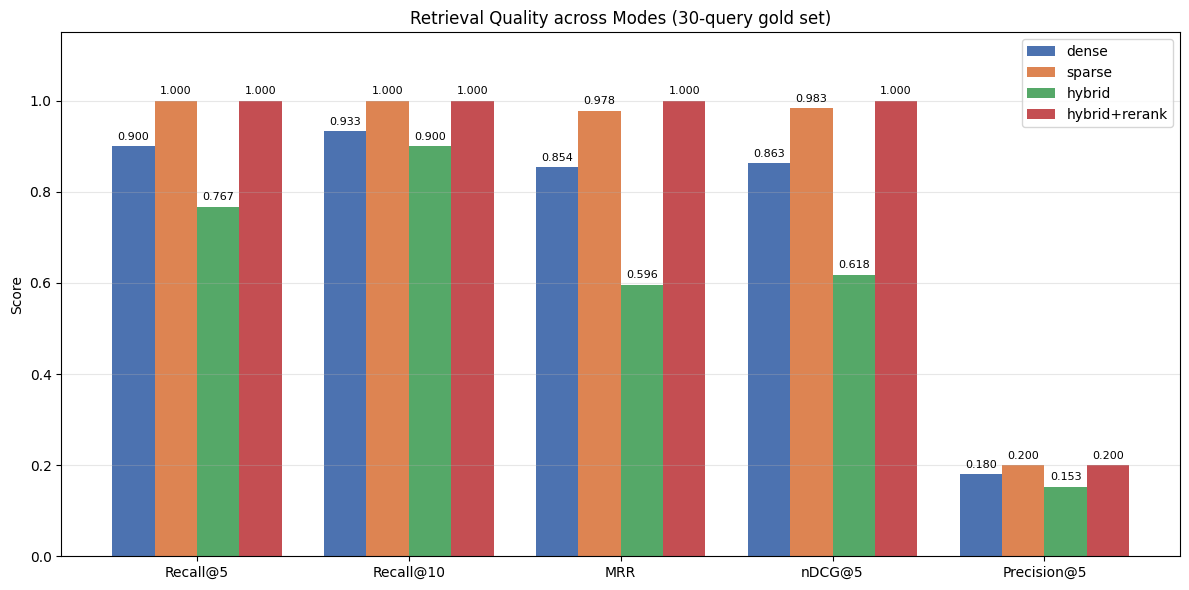

saved d2_metrics_comparison.png


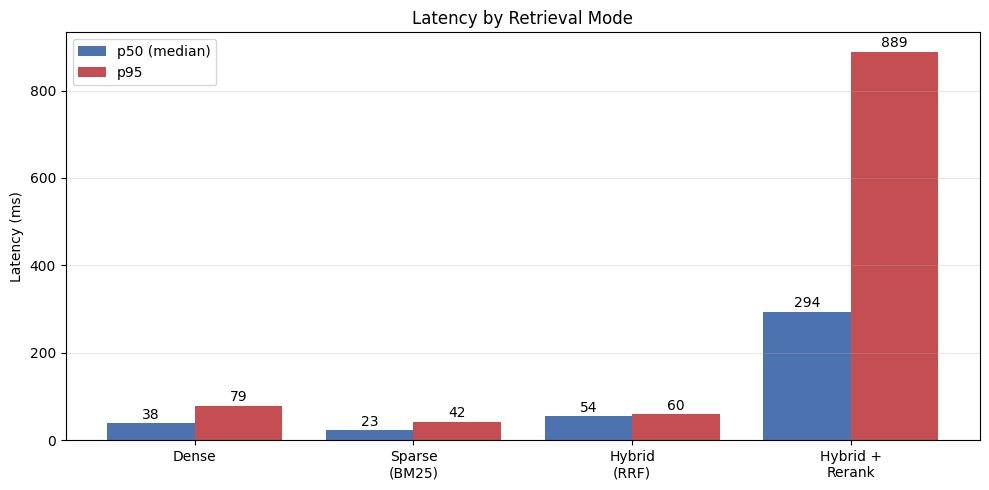

saved d2_latency_comparison.png

✅ Notebook 06 enhancements done.


In [28]:
# cell 10 — plots with verified metrics
import matplotlib.pyplot as plt
import numpy as np

# verified numbers from cell 9 output
data = {
    'dense':        {'recall@5':0.900,'recall@10':0.933,'mrr':0.854,'ndcg@5':0.863,'precision@5':0.180,'p50_ms':38.4,'p95_ms':79.1},
    'sparse':       {'recall@5':1.000,'recall@10':1.000,'mrr':0.978,'ndcg@5':0.983,'precision@5':0.200,'p50_ms':22.9,'p95_ms':42.5},
    'hybrid':       {'recall@5':0.767,'recall@10':0.900,'mrr':0.596,'ndcg@5':0.618,'precision@5':0.153,'p50_ms':54.1,'p95_ms':59.7},
    'hybrid_rerank':{'recall@5':1.000,'recall@10':1.000,'mrr':1.000,'ndcg@5':1.000,'precision@5':0.200,'p50_ms':293.8,'p95_ms':888.7},
}

metrics = ['Recall@5', 'Recall@10', 'MRR', 'nDCG@5', 'Precision@5']
keys = ['recall@5', 'recall@10', 'mrr', 'ndcg@5', 'precision@5']
dense_v  = [data['dense'][k] for k in keys]
sparse_v = [data['sparse'][k] for k in keys]
hybrid_v = [data['hybrid'][k] for k in keys]
rerank_v = [data['hybrid_rerank'][k] for k in keys]

x = np.arange(len(metrics))
width = 0.2
fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - 1.5*width, dense_v,  width, label='dense',         color='#4C72B0')
b2 = ax.bar(x - 0.5*width, sparse_v, width, label='sparse',        color='#DD8452')
b3 = ax.bar(x + 0.5*width, hybrid_v, width, label='hybrid',        color='#55A868')
b4 = ax.bar(x + 1.5*width, rerank_v, width, label='hybrid+rerank', color='#C44E52')
for bars in [b1, b2, b3, b4]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.3f}', ha='center', va='bottom', fontsize=8)
ax.set_ylabel('Score')
ax.set_title('Retrieval Quality across Modes (30-query gold set)')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'd2_metrics_comparison.png', dpi=150)
plt.show()
print('saved d2_metrics_comparison.png')

modes = ['Dense', 'Sparse\n(BM25)', 'Hybrid\n(RRF)', 'Hybrid +\nRerank']
p50 = [data['dense']['p50_ms'], data['sparse']['p50_ms'], data['hybrid']['p50_ms'], data['hybrid_rerank']['p50_ms']]
p95 = [data['dense']['p95_ms'], data['sparse']['p95_ms'], data['hybrid']['p95_ms'], data['hybrid_rerank']['p95_ms']]
x2 = np.arange(len(modes))
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x2 - 0.2, p50, 0.4, label='p50 (median)', color='#4C72B0')
b2 = ax.bar(x2 + 0.2, p95, 0.4, label='p95', color='#C44E52')
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 10, f'{h:.0f}', ha='center', fontsize=10)
ax.set_ylabel('Latency (ms)')
ax.set_title('Latency by Retrieval Mode')
ax.set_xticks(x2)
ax.set_xticklabels(modes)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'd2_latency_comparison.png', dpi=150)
plt.show()
print('saved d2_latency_comparison.png')
print('\n✅ Notebook 06 enhancements done.')